In [18]:
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from cinebot.config import settings

### Load the dataset 

In [2]:
data_path = settings.PREPROCESSED_DATA_PATH
df = pd.read_parquet(data_path)

In [3]:
df.sample(5)

,id,genres,Duration,Year_of_release,Title,Rating,Plot,Cast,Directors,combined_text_info
228,615457,"action,thriller",91,2021,nobody,7.884,"hutch mansell, a suburban dad, overlooked husb...","christopher lloyd,aleksey serebryakov,michael ...","vee tulloch,paul barry,reed makayev,ilya naish...","genres:action,thriller, title:nobody, plot:hut..."
540,572802,"action,adventure,fantasy",124,2023,aquaman and the lost kingdom,6.536,black manta seeks revenge on aquaman for his f...,"jason momoa,randall park,patrick wilson,amber ...","thomas bentley,mike deedigan,james wan,lee gru...","genres:action,adventure,fantasy, title:aquaman..."
284,205596,"history,drama,thriller,war",113,2014,the imitation game,7.987,based on the real life story of legendary cryp...,"matthew goode,benedict cumberbatch,allen leech...","phil booth,james manning,crispin reece,morten ...","genres:history,drama,thriller,war, title:the i..."
605,44833,"thriller,action,adventure,science fiction",131,2012,battleship,5.881,"when mankind beams a radio signal into space, ...","taylor kitsch,tadanobu asano,rihanna,alexander...","eric heffron,julie pitkanen,rebecca boyle,mich...","genres:thriller,action,adventure,science ficti..."
481,10555,"animation,action,comedy,family",90,2004,shark tale,6.032,oscar is a small fish whose big aspirations of...,"angelina jolie,robert de niro,jack black,will ...","vicky jenson,rob letterman,dan st. pierre,fabr...","genres:animation,action,comedy,family, title:s..."


### 1. Dataset Exploration

**Feature Descriptions**:

- Title - Title of the movie
- genres - All the genres in the movie
- Duration - Duration of the movie in minutes
- Year_of_release - Release year of the movie
- Rating - IMDb rating of the movie
- Plot - Short summary of the movie
- Cast - Names of 5 randomly selected Actors/Actresses
- Directors - Names of all the directors of the movie (including assistant directors, art directors, directors of photography etc..)
- combined_text_info - All the text info in the row merged into one single column for similarity search.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1000 non-null   int64  
 1   genres           1000 non-null   str    
 2   Duration         1000 non-null   int64  
 3   Year_of_release  1000 non-null   str    
 4   Title            1000 non-null   str    
 5   Rating           1000 non-null   float64
 6   Plot             1000 non-null   str    
 7   Cast             1000 non-null   str    
 8   Directors        1000 non-null   str    
dtypes: float64(1), int64(2), str(6)
memory usage: 559.0 KB


In [15]:
print(df.describe())

# Get the total number of unique Genres
genres = set()
for _, row in df.iterrows():
    list_of_genres = row['genres'].split(',')
    genres.update(set(list_of_genres))

number_of_genres = len(genres)
print("-"*50)
print(f"\nNo. of genres: {number_of_genres}")
print(f"\nGenres:\n {genres}")

                 id   Duration      Rating
count  9.990000e+02  999.00000  999.000000
mean   2.539186e+05  120.65966    7.187370
std    3.277289e+05   24.57711    0.675129
min    1.100000e+01   74.00000    4.324000
25%    2.180000e+03  103.00000    6.724000
50%    7.210500e+04  117.00000    7.222000
75%    4.208175e+05  132.50000    7.678000
max    1.376434e+06  253.00000    8.717000
--------------------------------------------------

No. of genres: 18

Genres:
 {'documentary', 'crime', 'science fiction', 'action', 'war', 'family', 'history', 'mystery', 'romance', 'horror', 'drama', 'western', 'comedy', 'animation', 'music', 'adventure', 'thriller', 'fantasy'}


### 2. EDA

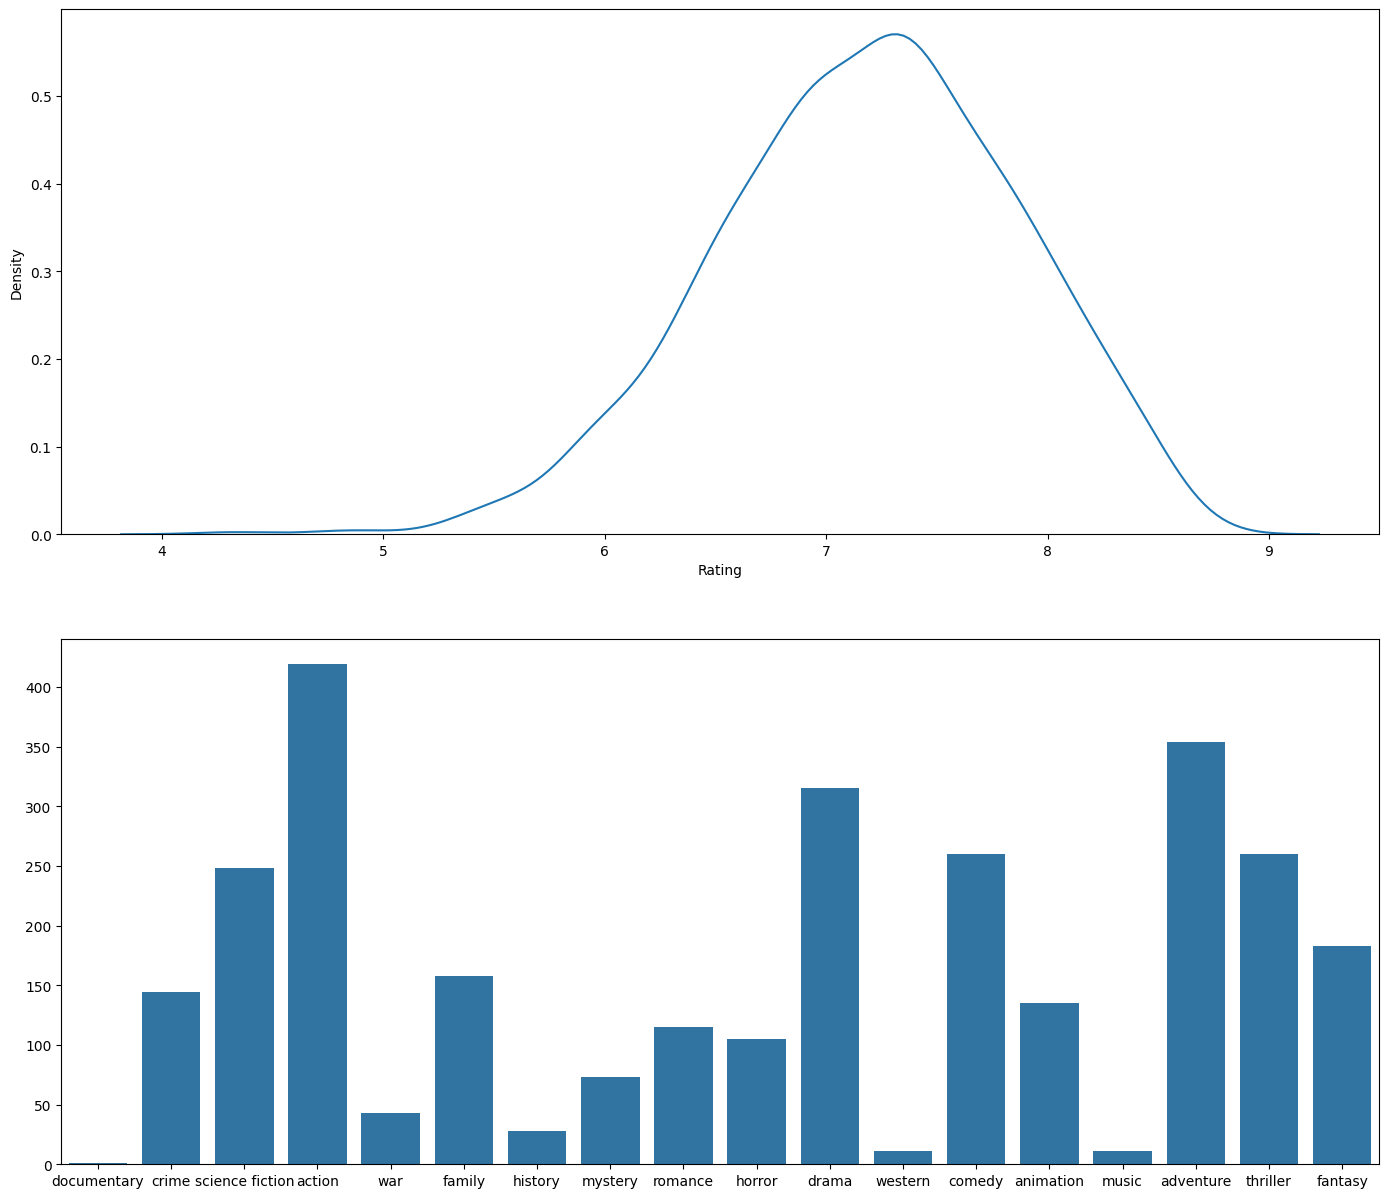

In [32]:
fig, ax = plt.subplots(2, 1, figsize=(17, 15))
ax = ax.flatten()

# Ratings Distribution
sns.kdeplot(df, x='Rating', ax=ax[0])


# Genres
def genre_freq(df, genre):
    return df['genres'].apply(lambda x : genre in x).sum()

genre_freq = {genre : genre_freq(df, genre) for genre in genres}
sns.barplot(genre_freq, ax=ax[1])
plt.show()